<a href="https://colab.research.google.com/github/np-helios/NishthaPandey_23fe10cse00774/blob/main/K_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

print("Path to dataset files:", path)

100%|██████████| 5.21k/5.21k [00:00<00:00, 2.03MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/rohan0301/unsupervised-learning-on-country-data/versions/2


In [2]:
import pandas as pd
import os

# Find CSV file inside downloaded folder
for file in os.listdir(path):
    if file.endswith(".csv"):
        data_file = os.path.join(path, file)

df = pd.read_csv(data_file)

print(df.head())

  Column Name                                        Description
0     country                                Name of the country
1  child_mort  Death of children under 5 years of age per 100...
2     exports  Exports of goods and services per capita. Give...
3      health  Total health spending per capita. Given as %ag...
4     imports  Imports of goods and services per capita. Give...


In [4]:
print(df.columns)

Index(['Column Name', 'Description'], dtype='object')


In [5]:
import os

print(os.listdir(path))

['Country-data.csv', 'data-dictionary.csv']


In [6]:
data_file = os.path.join(path, 'Country-data.csv')  # or similar name
df = pd.read_csv(data_file)

print(df.head())

               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [7]:
print(df.columns)

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


In [8]:
country_names = df['country']
X = df.drop('country', axis=1)

In [9]:
print(X.isnull().sum())

child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

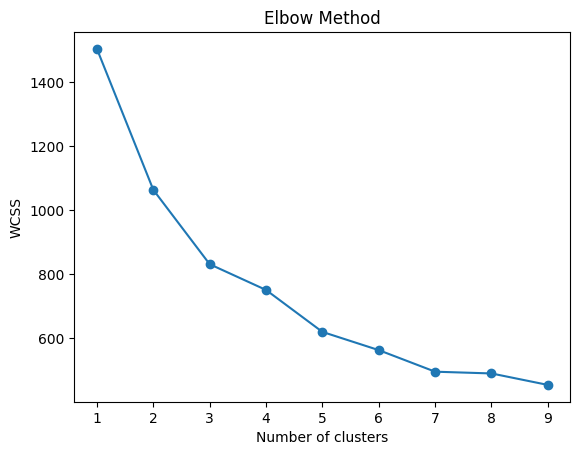

In [11]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 10):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 10), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

In [12]:
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_

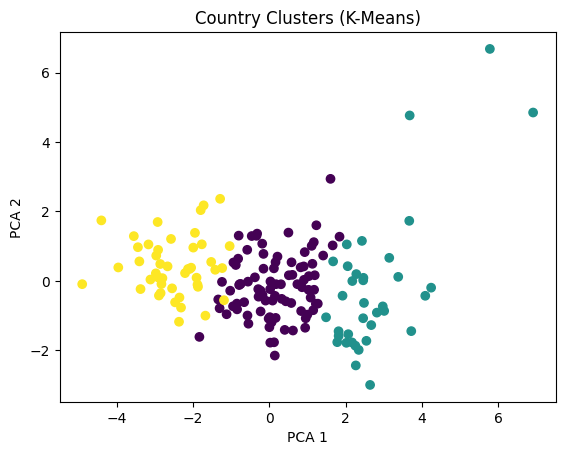

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'])
plt.title("Country Clusters (K-Means)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [15]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0         22.456977  40.273128  6.251047  47.362394  12321.744186   7.720884   
1          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
2         95.106667  28.602444  6.301111  42.306667   3539.844444  11.986778   

         life_expec  total_fer          gdpp  
Cluster                                       
0         72.566279   2.340349   6461.767442  
1         80.127778   1.752778  42494.444444  
2         59.055556   5.065333   1766.711111  


In [16]:
for i in range(k):
    print(f"\nCluster {i} Countries:")
    print(country_names[df['Cluster'] == i].values[:10])


Cluster 0 Countries:
['Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina' 'Armenia'
 'Azerbaijan' 'Bahamas' 'Bangladesh' 'Barbados' 'Belarus']

Cluster 1 Countries:
['Australia' 'Austria' 'Bahrain' 'Belgium' 'Brunei' 'Canada' 'Cyprus'
 'Czech Republic' 'Denmark' 'Finland']

Cluster 2 Countries:
['Afghanistan' 'Angola' 'Benin' 'Burkina Faso' 'Burundi' 'Cameroon'
 'Central African Republic' 'Chad' 'Comoros' 'Congo, Dem. Rep.']
